### Autor: David Roca Tauste
---

# Predicción de averías en equipos industriales

---
# 1. PREPARACIÓN

## 1.1. Carga de librerías

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

from keras_tuner import RandomSearch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

## 1.2. Carga del CSV y primeras observaciones de los datos

In [76]:
ruta = "equipment_anomaly_data.csv"
datos = pd.read_csv(ruta)

valor_objetivo = "faulty"

In [77]:
print(datos.shape)
print(f"La cantidad de filas es: {datos.shape[0]}")
print(f"La cantidad de columnas es: {datos.shape[1]}")

(7672, 7)
La cantidad de filas es: 7672
La cantidad de columnas es: 7


In [78]:
datos.describe()

,temperature,pressure,vibration,humidity,faulty
count,7672.000000,7672.000000,7672.000000,7672.000000,7672.000000
mean,70.922478,35.738048,1.611809,50.016574,0.099974
std,16.200059,10.381593,0.728560,11.841479,0.299985
min,10.269385,3.620798,-0.428188,10.215077,0.000000
25%,62.777057,29.485682,1.170906,42.612817,0.000000
50%,70.156900,35.227544,1.533113,50.024744,0.000000
75%,77.568387,41.159913,1.924700,57.340513,0.000000
max,149.690420,79.887734,4.990537,89.984718,1.000000


In [79]:
datos.head()

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0


---
# 2. LIMPIEZA DE DATOS

## 2.1. Gestión de valores nulos

In [80]:
print("Número de casillas nulas por columna:")
datos.isnull().sum()

Número de casillas nulas por columna:


temperature    0
pressure       0
vibration      0
humidity       0
equipment      0
location       0
faulty         0
dtype: int64

## 2.2. Tipos de datos de las columnas

In [81]:
datos.dtypes

temperature    float64
pressure       float64
vibration      float64
humidity       float64
equipment       object
location        object
faulty         float64
dtype: object

## 2.3. Gestión de anomalías (outliers)

In [82]:
columnas = datos.columns.values
print(columnas)

['temperature' 'pressure' 'vibration' 'humidity' 'equipment' 'location'
 'faulty']


### 2.3.2 Validación de valores float

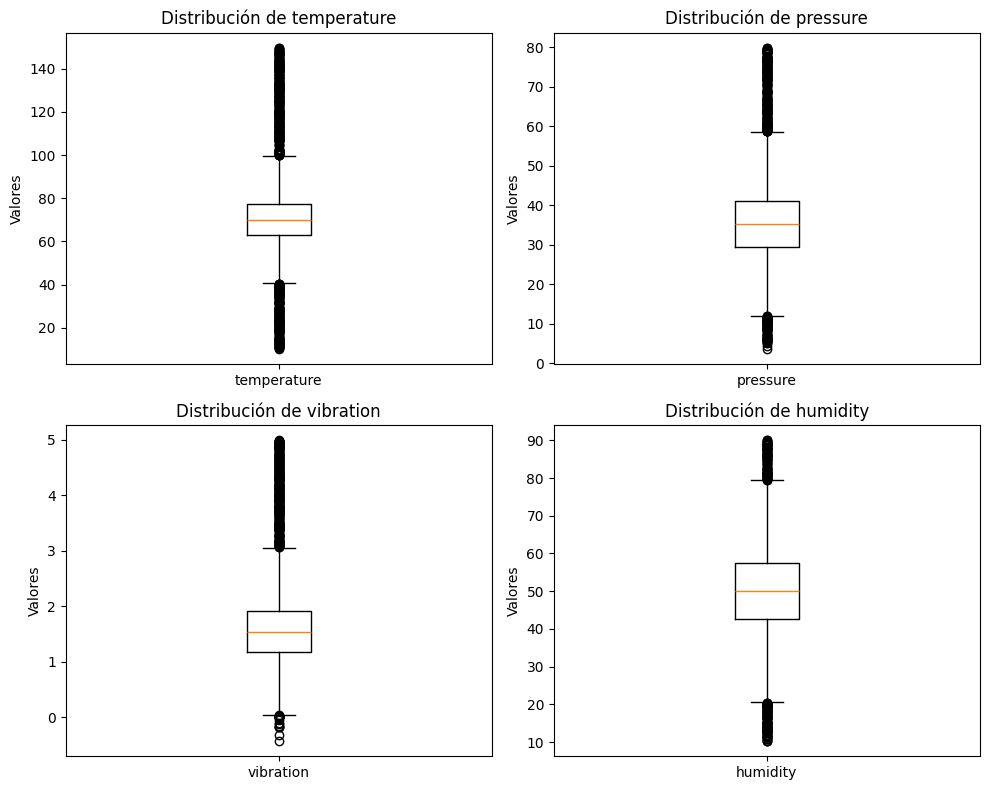

In [83]:
def comprobar_float_outliers_boxplot():
    # Valores float
    columnas_float = []

    for columna_actual in columnas:
        if (datos[columna_actual].dtype == "float64" and columna_actual != valor_objetivo):
            columnas_float.append(columna_actual)
        

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

    axes = axes.flatten()
    for i, var in enumerate(columnas_float):
        axes[i].boxplot(datos[var], tick_labels=[var])
        axes[i].set_title(f'Distribución de {var}')
        axes[i].set_ylabel('Valores')

    for j in range(len(columnas_float), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    return columnas_float

columnas_float = comprobar_float_outliers_boxplot()

In [85]:
datos.shape

(7672, 7)

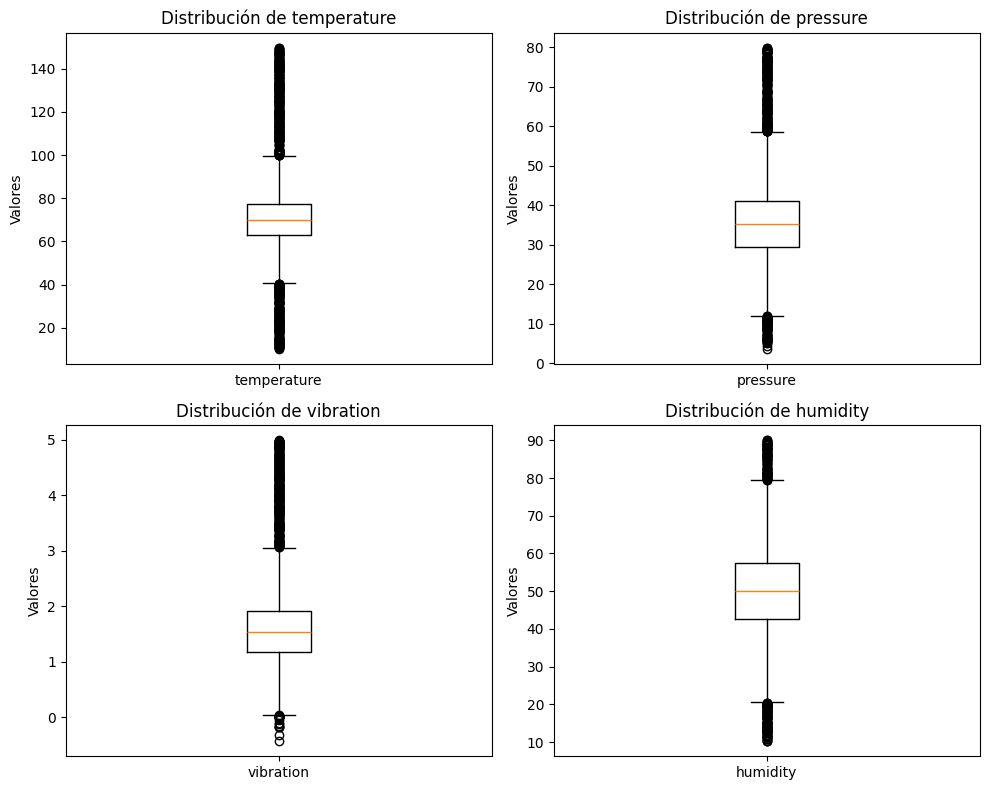

In [86]:
columnas_float = comprobar_float_outliers_boxplot()

### 2.3.3 Validación de valores object

In [87]:
columnas_objeto = datos.select_dtypes(include=['object']).columns

lista_columnas_objeto = list(columnas_objeto)
print(lista_columnas_objeto)

['equipment', 'location']


In [88]:
# Manera 1
"""
for columna_actual in lista_columnas_objeto:
    conteo = datos.groupby(columna_actual).size()
    print(f"{conteo}\n")
"""

# Manera 2
for columna_actual in lista_columnas_objeto:
    print(f"{datos[columna_actual].value_counts()}\n")

equipment
Compressor    2573
Turbine       2565
Pump          2534
Name: count, dtype: int64

location
Atlanta          1564
Chicago          1553
Houston          1548
New York         1526
San Francisco    1481
Name: count, dtype: int64



## 2.4 Comprobación y mejora de valor objetivo

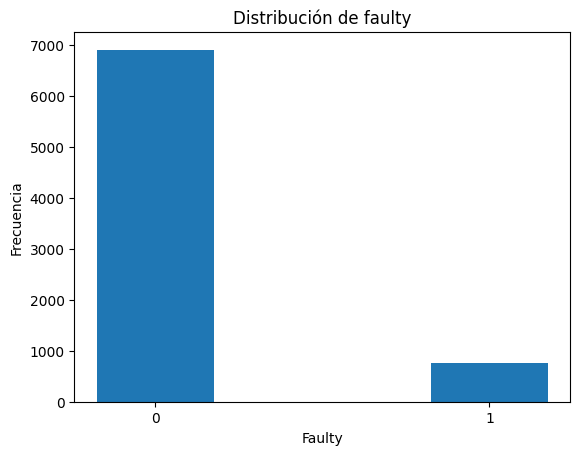

Cantidad de valores de la clase mayoritaria: 48335
Cantidad de valores de la clase minoritaria: 5369


In [89]:
def comprobar_balanceo_clases(datos_comprobacion):
    categorias = ['0', '1']

    valores = datos_comprobacion[valor_objetivo].value_counts()

    bar_width = 0.35
    x = np.arange(len(categorias))

    plt.bar(x, valores.values, bar_width,  label='Faulty')
    plt.xlabel('Faulty')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de faulty')
    plt.xticks(x, categorias)
    plt.show()

comprobar_balanceo_clases(datos)

# Comprobar
clase_mayoritaria = datos[datos[valor_objetivo] == 0]
clase_minoritaria = datos[datos[valor_objetivo] == 1]
print(f"Cantidad de valores de la clase mayoritaria: {clase_mayoritaria.size}")
print(f"Cantidad de valores de la clase minoritaria: {clase_minoritaria.size}")

---
# 3. Ingeniería de características
## 3.1. Codificación de variables categóricas

In [93]:
datos.head()

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0


In [94]:
datos = pd.get_dummies(datos, columns=['equipment'], prefix='equipment')
datos = pd.get_dummies(datos, columns=['location'], prefix='location')

In [95]:
datos.head()

,temperature,pressure,vibration,humidity,faulty,equipment_Compressor,equipment_Pump,equipment_Turbine,location_Atlanta,location_Chicago,location_Houston,location_New York,location_San Francisco
0,58.180180,25.029278,0.606516,45.694907,0.0,False,False,True,True,False,False,False,False
1,75.740712,22.954018,2.338095,41.867407,0.0,True,False,False,False,True,False,False,False
2,71.358594,27.276830,1.389198,58.954409,0.0,False,False,True,False,False,False,False,True
3,71.616985,32.242921,1.770690,40.565138,0.0,False,True,False,True,False,False,False,False
4,66.506832,45.197471,0.345398,43.253795,0.0,False,True,False,False,False,False,True,False


## 3.2. Selección de características

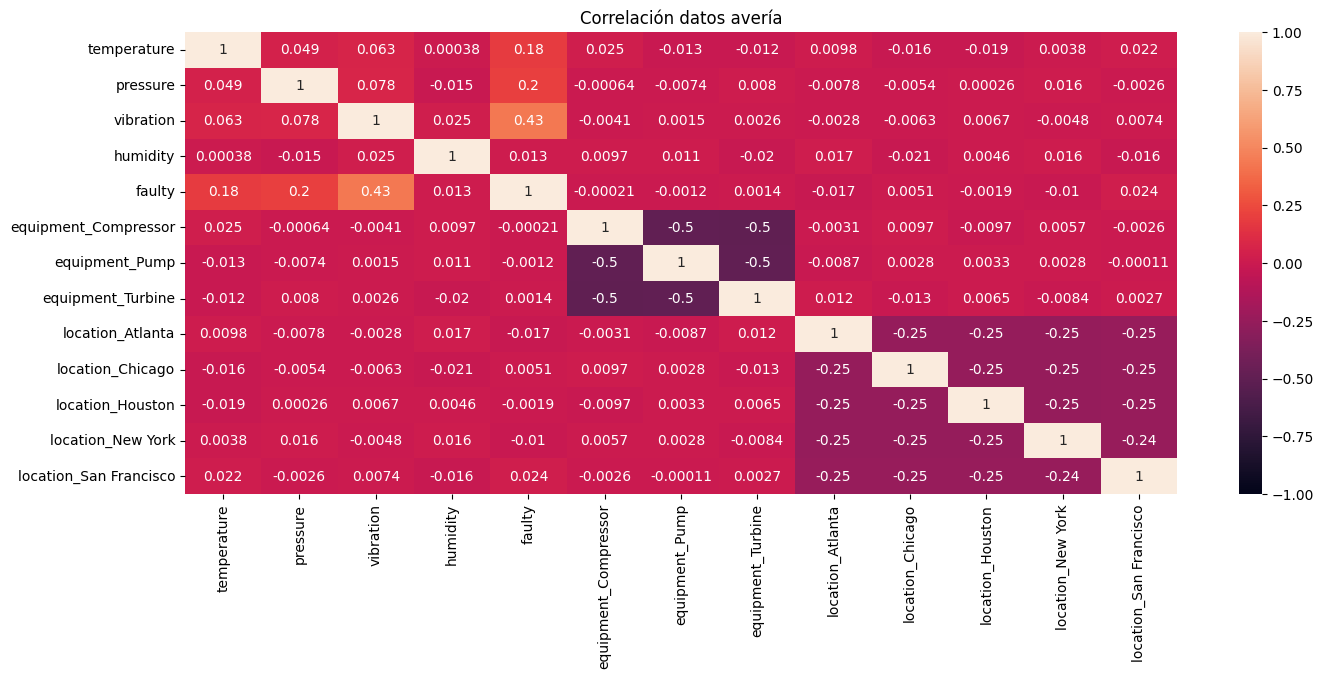

In [96]:
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(datos.corr(), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlación datos avería')

plt.show()

Es necesaria esta celda de código?

In [97]:
print(datos[valor_objetivo].describe())
datos.describe()

count    7672.000000
mean        0.099974
std         0.299985
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: faulty, dtype: float64


,temperature,pressure,vibration,humidity,faulty
count,7672.000000,7672.000000,7672.000000,7672.000000,7672.000000
mean,70.922478,35.738048,1.611809,50.016574,0.099974
std,16.200059,10.381593,0.728560,11.841479,0.299985
min,10.269385,3.620798,-0.428188,10.215077,0.000000
25%,62.777057,29.485682,1.170906,42.612817,0.000000
50%,70.156900,35.227544,1.533113,50.024744,0.000000
75%,77.568387,41.159913,1.924700,57.340513,0.000000
max,149.690420,79.887734,4.990537,89.984718,1.000000


In [98]:
columnas_relevantes = ['humidity', 'equipment_Compressor', 'equipment_Pump', 'vibration', 'location_San Francisco']
datos_relevantes = datos[columnas_relevantes + [valor_objetivo]]
datos_relevantes.head()

,humidity,equipment_Compressor,equipment_Pump,vibration,location_San Francisco,faulty
0,45.694907,False,False,0.606516,False,0.0
1,41.867407,True,False,2.338095,False,0.0
2,58.954409,False,False,1.389198,True,0.0
3,40.565138,False,True,1.770690,False,0.0
4,43.253795,False,True,0.345398,False,0.0


## 3.3. Escalado

In [99]:
se = StandardScaler()

for columna in columnas_relevantes:
    if (columna != valor_objetivo):
        datos_relevantes[columna] = se.fit_transform(datos[[columna]])

C:\Users\davil\AppData\Local\Temp\ipykernel_7152\3320685921.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos_relevantes[columna] = se.fit_transform(datos[[columna]])
C:\Users\davil\AppData\Local\Temp\ipykernel_7152\3320685921.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos_relevantes[columna] = se.fit_transform(datos[[columna]])
C:\Users\davil\AppData\Local\Temp\ipykernel_7152\3320685921.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

In [100]:
datos_relevantes.head()

,humidity,equipment_Compressor,equipment_Pump,vibration,location_San Francisco,faulty
0,-0.364984,-0.710358,-0.702273,-1.379925,-0.489099,0.0
1,-0.688233,1.407741,-0.702273,0.996943,-0.489099,0.0
2,0.754840,-0.710358,-0.702273,-0.305569,2.044574,0.0
3,-0.798215,-0.710358,1.423947,0.218089,-0.489099,0.0
4,-0.571147,-0.710358,1.423947,-1.738352,-0.489099,0.0


---
# 4. Análisis exploratorio de datos

No sé que poner aquí. He puesto esto por poner algo.

Text(0.5, 1.0, 'Distribución de valores de faulty')

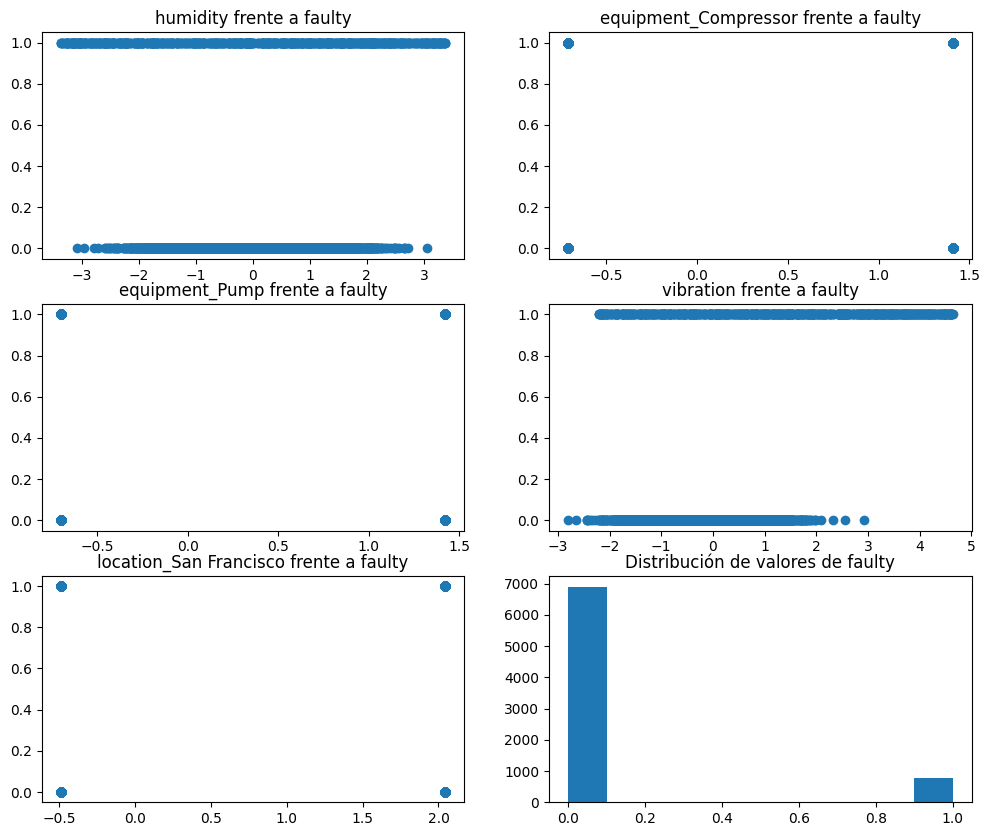

In [101]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))

for i in range(0, len(columnas_relevantes)):
    fila = i // 2
    columna = i % 2
    ax[fila, columna].scatter(x = datos_relevantes[columnas_relevantes[i]], y = datos_relevantes[valor_objetivo])
    ax[fila, columna].set_title(columnas_relevantes[i] + " frente a " + valor_objetivo)
    
ax[2, 1].hist(datos_relevantes[valor_objetivo], bins=10)
ax[2, 1].set_title("Distribución de valores de " + valor_objetivo)

---
# 5. Desarrollo de un modelo supervisado de clasificación

## 5.1. Preparación de los conjuntos train y test

In [102]:
X = datos_relevantes.iloc[:, :-1].values
y = datos_relevantes.iloc[:, -1].values

# Si, por ejemplo, el target se encontrase en la segunda columna, habría que hacer esto:
"""
X = datos_relevantes.drop(datos_relevantes.columns[1], axis=1).values
y = datos_relevantes.iloc[:, 1].values
"""

# Otra manera. En este caso es independiente de la posición en la que se encuentre:
"""
if valor_objetivo in datos_relevantes.columns:
    X = datos_relevantes.drop(columns=[valor_objetivo])  # No hace falta: .values
    y = datos_relevantes[valor_objetivo]  # No hace falta: .values
"""


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

`IMPORTANTE`

```python
if valor_objetivo in datos_relevantes.columns:
    X = datos_relevantes.drop(columns=[valor_objetivo]).values
    y = datos_relevantes[valor_objetivo].values

In [103]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report

balanceador_smote = SMOTE(sampling_strategy="auto", random_state=42)
X_train_balanceado, y_train_balanceado = balanceador_smote.fit_resample(X_train, y_train)

## 5.3. Entrenamiento y métricas de validación del modelo

### MODELO 4 (el mejor)

In [104]:
# Creamos el modelo de red neuronal
modelo = Sequential([
    Input(shape=(X_train_balanceado.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

modelo.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

# Mostramos configuración
modelo.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor="val_loss", patience=10)

history = modelo.fit(
    X_train_balanceado,
    y_train_balanceado,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stopping],
)

Epoch 1/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7421 - loss: 0.5599 - val_accuracy: 0.8697 - val_loss: 0.3423
Epoch 2/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8615 - loss: 0.3438 - val_accuracy: 0.9140 - val_loss: 0.2660
Epoch 3/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8653 - loss: 0.3401 - val_accuracy: 0.8919 - val_loss: 0.2956
Epoch 4/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8620 - loss: 0.3442 - val_accuracy: 0.8938 - val_loss: 0.2980
Epoch 5/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8645 - loss: 0.3316 - val_accuracy: 0.9107 - val_loss: 0.2727
Epoch 6/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8613 - loss: 0.3295 - val_accuracy: 0.9231 - val_loss: 0.2345
Epoch 7/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8742 - loss: 0.3170 - val_accuracy: 0.9212 - val_loss: 0.2638
Epoch 8/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8669 - loss: 0.3213 - val_accuracy: 0.

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9317 - loss: 0.2516
Pérdida: 0.2483210414648056, Precisión: 0.9283387660980225


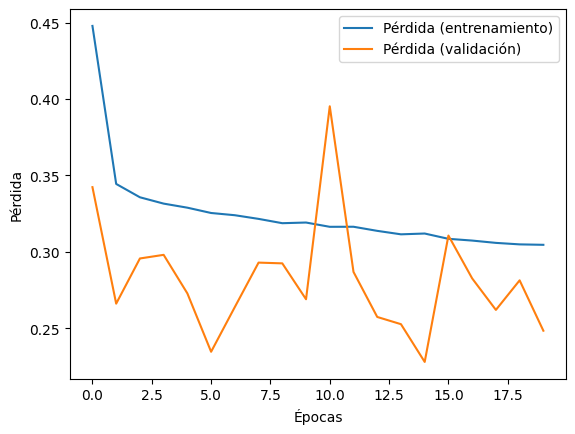

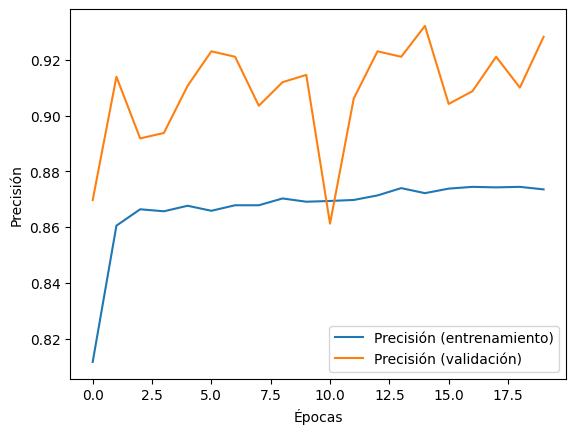

In [106]:
def graficas_evaluacion_modelo():
    loss, accuracy = modelo.evaluate(X_test, y_test)
    print(f"Pérdida: {loss}, Precisión: {accuracy}")

    # Pérdida
    plt.plot(history.history['loss'], label='Pérdida (entrenamiento)')
    plt.plot(history.history['val_loss'], label='Pérdida (validación)')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()

    # Precisión
    plt.plot(history.history['accuracy'], label='Precisión (entrenamiento)')
    plt.plot(history.history['val_accuracy'], label='Precisión (validación)')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    plt.show()
    
graficas_evaluacion_modelo()

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report:
              precision    recall  f1-score   support

   No avería       0.97      0.95      0.96      1377
      Avería       0.62      0.77      0.69       158

    accuracy                           0.93      1535
   macro avg       0.80      0.86      0.82      1535
weighted avg       0.94      0.93      0.93      1535



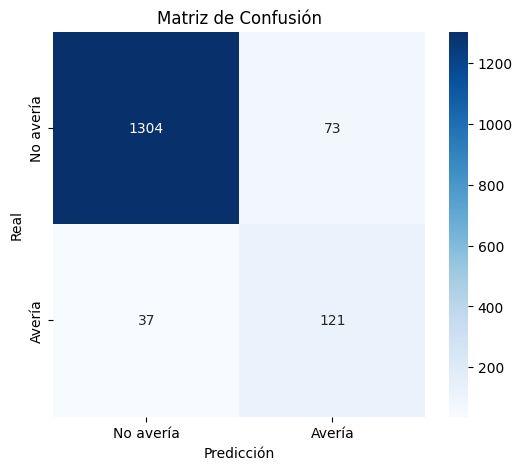

In [107]:
def train_validation(model):
    y_pred = model.predict(X_test)
    y_pred = np.round(y_pred).astype(int)

    conf_matrix = confusion_matrix(y_test, y_pred)

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["No avería", "Avería"]))

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No avería", "Avería"],
        yticklabels=["No avería", "Avería"],
    )
    plt.title("Matriz de Confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    # Métricas adicionales
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)


train_validation(modelo)

### MODELO 1

In [29]:
# Creamos el modelo de red neuronal
modelo = Sequential([
    Input(shape=(X_train.shape[1],)), # Entrada
    Dense(16, activation='relu'), # 1a capa oculta
    Dense(8, activation='relu'), # 2a capa oculta
    Dense(1, activation='sigmoid') # Salida
])

modelo.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

# Mostramos configuración
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = modelo.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5397 - loss: 0.7142 - val_accuracy: 0.6551 - val_loss: 0.6296
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6843 - loss: 0.6146 - val_accuracy: 0.7267 - val_loss: 0.5710
Epoch 3/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7310 - loss: 0.5567 - val_accuracy: 0.7613 - val_loss: 0.5258
Epoch 4/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7737 - loss: 0.5046 - val_accuracy: 0.7729 - val_loss: 0.4975
Epoch 5/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7759 - loss: 0.4761 - val_accuracy: 0.7701 - val_loss: 0.4822
Epoch 6/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7841 - loss: 0.4659 - val_accuracy: 0.7830 - val_loss: 0.4725
Epoch 7/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7853 - loss: 0.4561 - val_accuracy: 0.7890 - val_loss: 0.4644
Epoch 8/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8065 - loss: 0.4474 - val_accuracy: 0.

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8392 - loss: 0.3908
Pérdida: 0.3845652639865875, Precisión: 0.8478019833564758


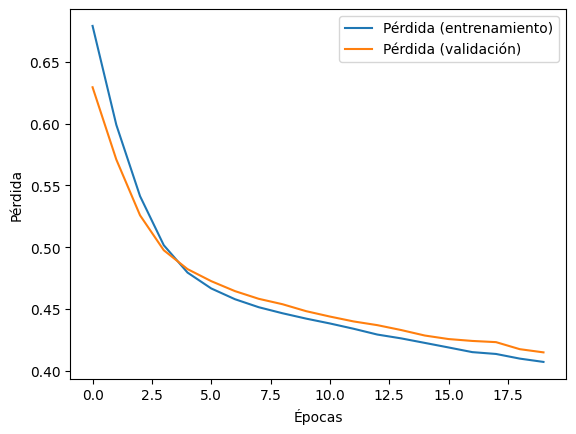

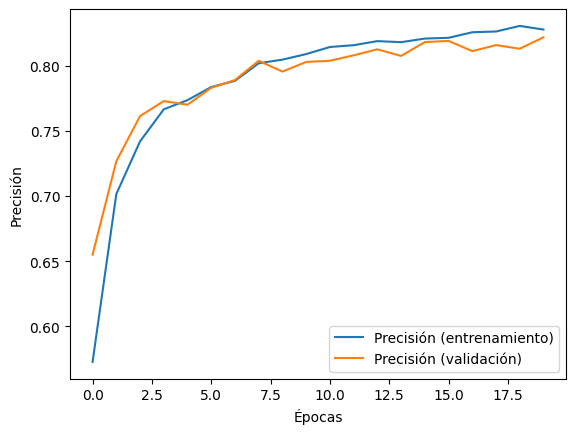

In [31]:
graficas_evaluacion_modelo()

### MODELO 2

In [32]:
# Creamos el modelo de red neuronal
modelo = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

modelo.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

# Mostramos configuración
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865 (3.38 KB)

 Trainable params: 865 (3.38 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = modelo.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6111 - loss: 0.6652 - val_accuracy: 0.6944 - val_loss: 0.5547
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6945 - loss: 0.5336 - val_accuracy: 0.7179 - val_loss: 0.5036
Epoch 3/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7492 - loss: 0.4906 - val_accuracy: 0.7752 - val_loss: 0.4861
Epoch 4/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7937 - loss: 0.4731 - val_accuracy: 0.7881 - val_loss: 0.4695
Epoch 5/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7883 - loss: 0.4700 - val_accuracy: 0.7973 - val_loss: 0.4597
Epoch 6/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8169 - loss: 0.4459 - val_accuracy: 0.8052 - val_loss: 0.4427
Epoch 7/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8255 - loss: 0.4313 - val_accuracy: 0.8102 - val_loss: 0.4325
Epoch 8/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8263 - loss: 0.4229 - val_accuracy: 0.

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8725 - loss: 0.3006
Pérdida: 0.29574713110923767, Precisión: 0.8673808574676514


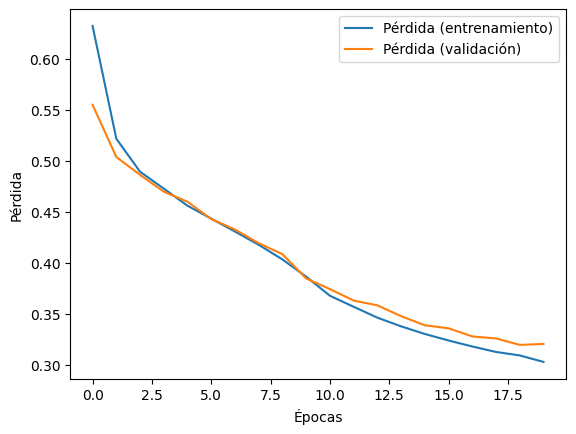

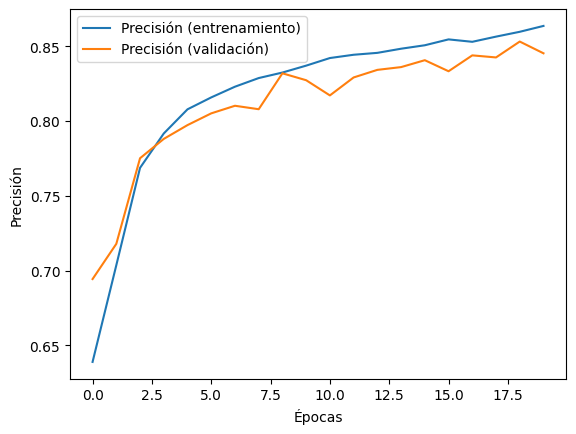

In [34]:
graficas_evaluacion_modelo()

### MODELO 3

In [35]:
# Creamos el modelo de red neuronal
modelo = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

modelo.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

# Mostramos configuración
modelo.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113 (452.00 B)

 Trainable params: 113 (452.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = modelo.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5455 - loss: 0.6996 - val_accuracy: 0.6408 - val_loss: 0.6314
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6452 - loss: 0.6214 - val_accuracy: 0.6782 - val_loss: 0.5940
Epoch 3/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6851 - loss: 0.5823 - val_accuracy: 0.7050 - val_loss: 0.5680
Epoch 4/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7149 - loss: 0.5555 - val_accuracy: 0.7428 - val_loss: 0.5471
Epoch 5/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7434 - loss: 0.5318 - val_accuracy: 0.7401 - val_loss: 0.5301
Epoch 6/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7410 - loss: 0.5216 - val_accuracy: 0.7428 - val_loss: 0.5192
Epoch 7/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7503 - loss: 0.5075 - val_accuracy: 0.7470 - val_loss: 0.5110
Epoch 8/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7614 - loss: 0.5005 - val_accuracy: 0.

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7975 - loss: 0.4537  
Pérdida: 0.4498913884162903, Precisión: 0.800517201423645


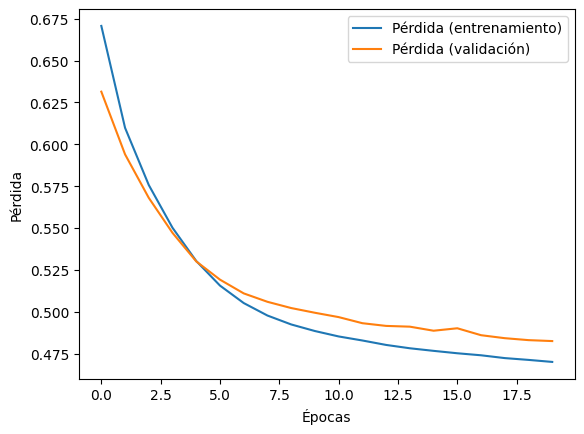

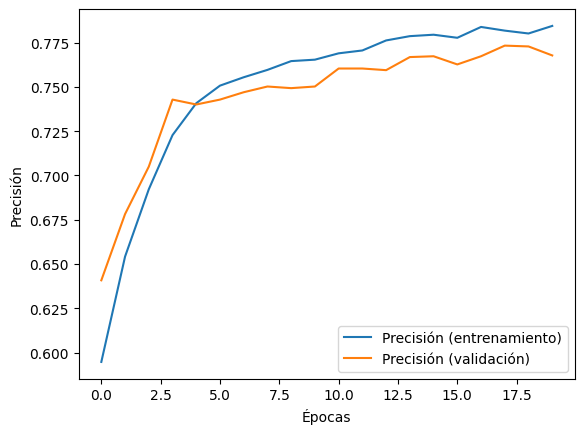

In [37]:
graficas_evaluacion_modelo()

### Tuning de hiperparámetros

In [42]:
def build_model(hp):
    modelo = Sequential(
        [
            Dense(
                units=hp.Int("units", min_value=32, max_value=512, step=32),
                activation="relu",
            ),
            Dense(1),
        ]
    )

    modelo.compile(
        optimizer=Adam(
            learning_rate=hp.Choice("learning_rate", [0.001, 0.01])
        ),
        loss="mean_squared_error",
        metrics=["mae"],
    )
    return modelo


tuner = RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=5,
    directory="my_dir",
    project_name="intro_hyperparameters",
)
tuner.search(X_train, y_train, epochs=10, validation_split=0.2)

'\ndef build_model(hp):\n    modelo = Sequential(\n        [\n            Dense(\n                units=hp.Int("units", min_value=32, max_value=512, step=32),\n                activation="relu",\n            ),\n            Dense(1),\n        ]\n    )\n\n    modelo.compile(\n        optimizer=Adam(\n            learning_rate=hp.Choice("learning_rate", [0.001, 0.01])\n        ),\n        loss="mean_squared_error",\n        metrics=["mae"],\n    )\n    return modelo\n\n\ntuner = RandomSearch(\n    build_model,\n    objective="val_loss",\n    max_trials=5,\n    directory="my_dir",\n    project_name="intro_hyperparameters",\n)\ntuner.search(X_train, y_train, epochs=10, validation_split=0.2)\n'